# HW4: Palmer Penguins — Summary Statistics & Plots

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


In [27]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [28]:
# a
print("Shape of dataset:")
print(penguins.shape)

Shape of dataset:
(344, 8)


In [29]:
# b
print("Column names:")
print(penguins.columns)

print("\nData types:")
print(penguins.dtypes)

Column names:
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='str')

Data types:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object


In [30]:
# c
print("Missing values:")
print(penguins.isna().sum())

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [31]:
# d
print("Species counts:")
print(penguins["species"].value_counts())

print("Sex counts:")
print(penguins["sex"].value_counts())

Species counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
Sex counts:
sex
male      168
female    165
Name: count, dtype: int64


### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [32]:
penguins_clean = penguins.dropna(
    subset=[
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "sex"
    ]
)


print("New shape:")
print(penguins_clean.shape)


New shape:
(333, 8)


### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [33]:
# a
print("Summary statistics:")
print(penguins_clean.describe())

# b
print("Mean by species:")
print(penguins_clean.groupby("species").mean(numeric_only=True))

print("\nStandard deviation by species:")
print(penguins_clean.groupby("species").std(numeric_only=True))


Summary statistics:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g      year
count         333.000        333.000            333.000      333.000   333.000
mean           43.993         17.165            200.967     4207.057  2008.042
std             5.469          1.969             14.016      805.216     0.813
min            32.100         13.100            172.000     2700.000  2007.000
25%            39.500         15.600            190.000     3550.000  2007.000
50%            44.500         17.300            197.000     4050.000  2008.000
75%            48.600         18.700            213.000     4775.000  2009.000
max            59.600         21.500            231.000     6300.000  2009.000
Mean by species:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
species                                                                    
Adelie             38.824         18.347            190.103     3706.164   
Chinstrap          48.83

### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [34]:
# a
grouped_summary = penguins_clean.groupby(["species", "sex"])[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g"
    ]
].agg(["mean", "count"])

print(grouped_summary)


                 bill_length_mm       bill_depth_mm       flipper_length_mm  \
                           mean count          mean count              mean   
species   sex                                                                 
Adelie    female         37.258    73        17.622    73           187.795   
          male           40.390    73        19.073    73           192.411   
Chinstrap female         46.574    34        17.588    34           191.735   
          male           51.094    34        19.253    34           199.912   
Gentoo    female         45.564    58        14.238    58           212.707   
          male           49.474    61        15.718    61           221.541   

                       body_mass_g        
                 count        mean count  
species   sex                             
Adelie    female    73    3368.836    73  
          male      73    4043.493    73  
Chinstrap female    34    3527.206    34  
          male      34    3938

In [35]:
# b

largest_body_mass = penguins_clean.groupby(
    ["species", "sex"]
)["body_mass_g"].mean().sort_values(ascending=False)

print(largest_body_mass.head(1))

species  sex 
Gentoo   male    5484.836
Name: body_mass_g, dtype: float64


### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [36]:
# a
penguins_clean.corr(numeric_only=True)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000,-0.229,0.653,0.589,0.033
bill_depth_mm,-0.229,1.000,-0.578,-0.472,-0.048
flipper_length_mm,0.653,-0.578,1.000,0.873,0.151
body_mass_g,0.589,-0.472,0.873,1.000,0.022
year,0.033,-0.048,0.151,0.022,1.000


In [37]:
# b
penguins_clean.groupby("species").corr(numeric_only=True)

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.465   
          year                        0.011         -0.235              0.328   
Chinstrap bill_length_mm              1.000          0.654              0.472   
          bill_depth_mm               0.654          1.000              0.580   
          flipper_length_mm           0.472          0.580              1.000   
          body_mass_g                 0.514          0.604              0.642   
          year                        0.042         -0.059              0.346   
Gentoo    bill_length_mm              1.000          0.654              0.664   
          bill_depth_mm               0.654          1.000              0.711   
          flipper_length_mm           0.664          0.711              1.000   
          body_mass_g                 0.667          0.723              0.711   
          year                        0.205          0.243              0.201   

                             body_mass_g   year  
species                                          
Adelie    bill_length_mm           0.544  0.011  
          bill_depth_mm            0.580 -0.235  
          flipper_length_mm        0.465  0.328  
          body_mass_g              1.000 -0.046  
          year                    -0.046  1.000  
Chinstrap bill_length_mm           0.514  0.042  
          bill_depth_mm            0.604 -0.059  
          flipper_length_mm        0.642  0.346  
          body_mass_g              1.000  0.037  
          year                     0.037  1.000  
Gentoo    bill_length_mm           0.667  0.205  
          bill_depth_mm            0.723  0.243  
          flipper_length_mm        0.711  0.201  
          body_mass_g              1.000  0.052  
          year                     0.052  1.000

In [38]:
#c
print("Overall:")
print(penguins_clean[["bill_length_mm", "bill_depth_mm"]].corr())

print("By species:")
print(penguins_clean.groupby("species")[["bill_length_mm", "bill_depth_mm"]].corr())

Overall:
                bill_length_mm  bill_depth_mm
bill_length_mm           1.000         -0.229
bill_depth_mm           -0.229          1.000
By species:
                          bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm           1.000          0.386
          bill_depth_mm            0.386          1.000
Chinstrap bill_length_mm           1.000          0.654
          bill_depth_mm            0.654          1.000
Gentoo    bill_length_mm           1.000          0.654
          bill_depth_mm            0.654          1.000


An example of Simpson's Paradox is the relationship between bill_length_mm and bill_depth_mm. The overall correlation is negative, but within each species the correlation is positive.

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


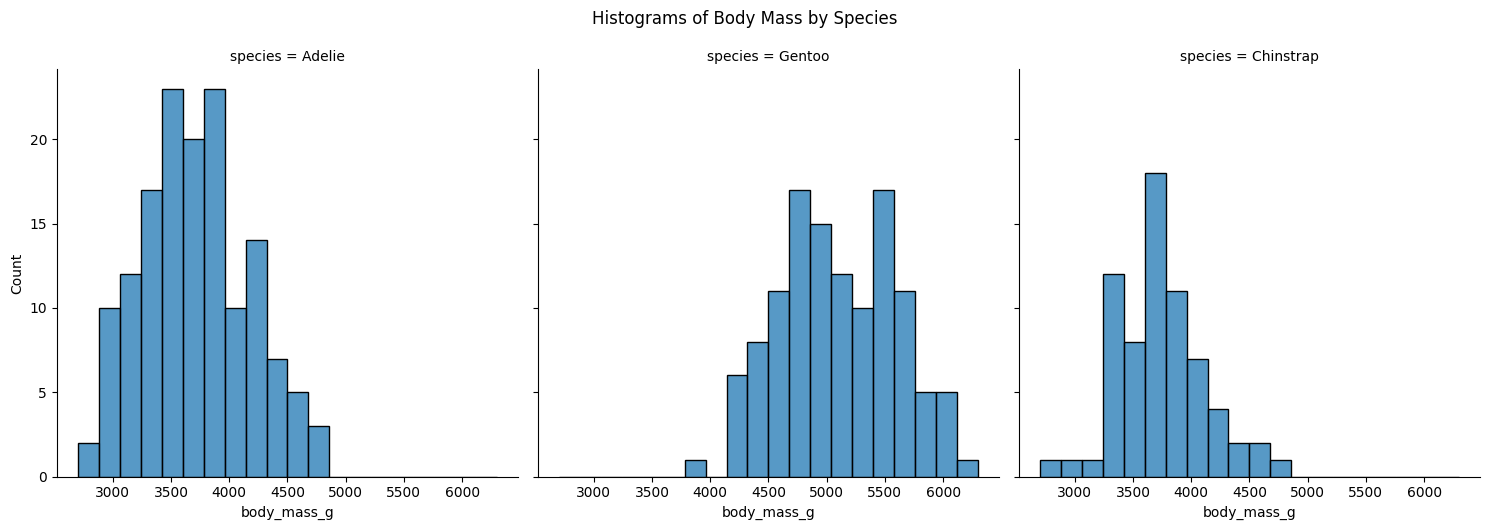

In [39]:
sns.displot(
    data=penguins_clean,
    x="body_mass_g",
    col="species",
    bins=20
)

plt.suptitle("Histograms of Body Mass by Species", y=1.05)
plt.show()

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

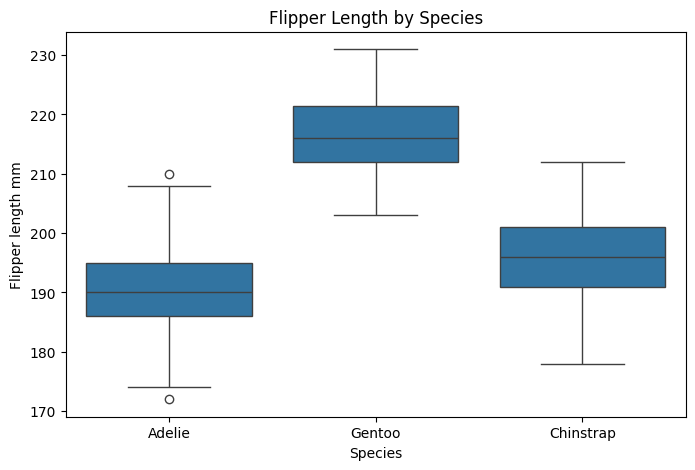

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=penguins_clean,
    x="species",
    y="flipper_length_mm"
)

plt.title("Flipper Length by Species")
plt.xlabel("Species")
plt.ylabel("Flipper length mm")
plt.show()

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

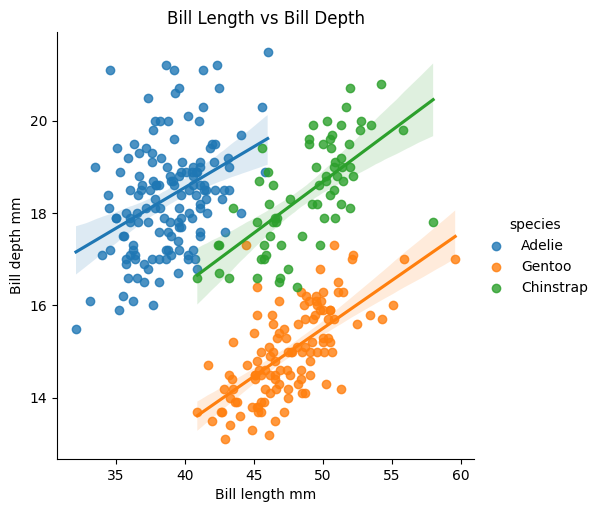

In [41]:
sns.lmplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)

plt.title("Bill Length vs Bill Depth")
plt.xlabel("Bill length mm")
plt.ylabel("Bill depth mm")
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

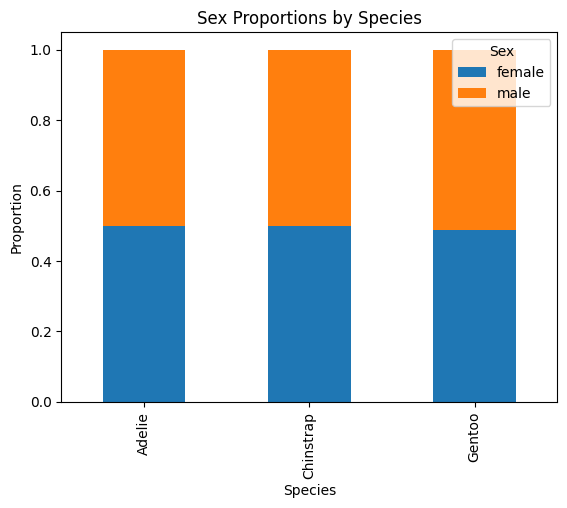

In [42]:
sex_props = pd.crosstab(
    penguins_clean["species"],
    penguins_clean["sex"],
    normalize="index"
)

sex_props.plot(kind="bar", stacked=True)

plt.title("Sex Proportions by Species")
plt.xlabel("Species")
plt.ylabel("Proportion")
plt.legend(title="Sex")
plt.show()